# Stage 0 — Lensing Simulation Prototype

**Goal:** Take real COSMOS galaxy cutouts from the previous notebook and simulate gravitational lensing  
to produce matched (LR 64×64, HR 128×128) image pairs at HSC instrument specifications.

---
### Pipeline position
```
01_cosmos_cutout_extraction.ipynb
    -> cosmos_cutouts/npy/galaxy_XXXX.npy     (50 source galaxies)
         |
         v
THIS NOTEBOOK (02_lensing_simulation_prototype.ipynb)
    -> SIE lens + Moffat PSF + HSC noise -> HR 128x128
    -> Downsample 2x                     -> LR  64x64
    -> Arc morphology validation against real HSC images
         |
         v
03_full_stage0_pipeline.py    (scale up to 60,000 pairs)
```

### Key parameters (HSC instrument)
| Parameter | Value | Source |
|-----------|-------|--------|
| LR pixel scale | 0.168 arcsec/px | HSC native pixel scale |
| HR pixel scale | 0.084 arcsec/px | 2x super-resolution target |
| LR image size | 64 × 64 px = 10.75" FoV | Matches DiffLense |
| HR image size | 128 × 128 px = 10.75" FoV | Same sky coverage, 2x resolution |
| PSF type | Moffat β=3.0 | Approximates atmospheric seeing |
| PSF FWHM | 0.6 – 0.9 arcsec | HSC i-band typical seeing |
| Sky background rms | 0.03 – 0.05 | HSC deep survey level |
| Einstein radius | 0.8 – 1.3 arcsec | Typical galaxy-scale strong lens |

## Cell 1 — Install dependencies

In [1]:
import subprocess, sys

packages = ['lenstronomy', 'numpy', 'matplotlib', 'scipy', 'tqdm', 'pandas', 'astropy']

for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    print(f'[{"OK" if result.returncode == 0 else "FAIL"}] {pkg}')

import lenstronomy
print(f'\nlenstronomy version: {lenstronomy.__version__}')

[OK] lenstronomy
[OK] numpy
[OK] matplotlib
[OK] scipy
[OK] tqdm
[OK] pandas
[OK] astropy

lenstronomy version: 1.14.0


## Cell 2 — Imports and configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import warnings
from pathlib import Path
from tqdm.notebook import tqdm
from scipy.ndimage import zoom

# lenstronomy imports
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.Util import kernel_util

warnings.filterwarnings('ignore')

# ── Instrument parameters ──────────────────────────────────────────────────────

# HSC pixel scale (native resolution = LR)
PIX_LR = 0.168     # arcsec/px  — HSC i-band

# HR pixel scale = 2x super-resolution target
# We simulate at this finer scale, then downsample to get LR
PIX_HR = PIX_LR / 2.0   # = 0.084 arcsec/px

# Image sizes
N_HR   = 128    # HR image: 128x128 px
N_LR   = 64     # LR image: 64x64 px  (= HR / 2)
FOV    = N_HR * PIX_HR   # Field of view in arcsec (same for HR and LR)

# PSF: Moffat profile approximating atmospheric seeing
# beta=3.0 is standard for ground-based seeing PSFs
PSF_FWHM_ARCSEC  = 0.7    # arcsec; typical HSC i-band seeing
PSF_MOFFAT_BETA  = 3.0    # Moffat beta parameter
PSF_KERNEL_SIZE  = 21     # pixels (must be odd); 21px x 0.084"/px = 1.76" kernel

# Noise parameters at HSC deep survey levels
# sky_rms is the background RMS per pixel in normalised flux units
# Typical HSC values after flux normalisation: 0.03-0.05
SKY_RMS       = 0.04    # background rms per pixel
EXPOSURE_TIME = 1800.0  # seconds; used to scale Poisson noise

# Lens parameters (varied per simulation in the full pipeline)
EINSTEIN_RADIUS = 1.0   # arcsec; typical galaxy-scale strong lens

# COSMOS source image pixel scale (from notebook 01)
SRC_PIX_SCALE = 0.03    # arcsec/px  (native ACS scale)

# lenstronomy supersampling for the source plane
# Higher = more accurate arc rendering, but slower
# 3 is a good balance for prototype work
SUPERSAMPLING = 3

# Random seed
RNG_SEED = 42
RNG      = np.random.default_rng(RNG_SEED)

# Paths
SRC_DIR  = Path('cosmos_irsa_auto/npy')
META_PATH = Path('cosmos_irsa_auto/metadata/cutout_metadata.json')
OUT_DIR  = Path('lensing_sim_output')
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / 'hr').mkdir(exist_ok=True)
(OUT_DIR / 'lr').mkdir(exist_ok=True)

print(f'HR: {N_HR}x{N_HR} px @ {PIX_HR}"/px  =  {N_HR*PIX_HR:.2f}" FoV')
print(f'LR: {N_LR}x{N_LR} px @ {PIX_LR}"/px  =  {N_LR*PIX_LR:.2f}" FoV')
print(f'PSF: Moffat  FWHM={PSF_FWHM_ARCSEC}"  beta={PSF_MOFFAT_BETA}')
print(f'Sky background rms: {SKY_RMS}  Exposure: {EXPOSURE_TIME}s')
print(f'Einstein radius: {EINSTEIN_RADIUS}"')
print(f'Output directory: {OUT_DIR.resolve()}')

HR: 128x128 px @ 0.084"/px  =  10.75" FoV
LR: 64x64 px @ 0.168"/px  =  10.75" FoV
PSF: Moffat  FWHM=0.7"  beta=3.0
Sky background rms: 0.04  Exposure: 1800.0s
Einstein radius: 1.0"
Output directory: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\stage_0\lensing_sim_output


## Cell 3 — Load COSMOS cutouts and metadata

In [3]:
# # Load all .npy galaxy cutouts from notebook 01
# npy_files = sorted(SRC_DIR.glob('cosmos_*.npy'))
# assert len(npy_files) > 0, f'No .npy files found in {SRC_DIR}. Run notebook 01 first.'
#
# source_galaxies = [np.load(f).astype(np.float32) for f in npy_files]
# print(f'Loaded {len(source_galaxies)} source galaxy cutouts.')
# print(f'Shape: {source_galaxies[0].shape}  dtype: {source_galaxies[0].dtype}')
# print(f'Value range: [{source_galaxies[0].min():.4f}, {source_galaxies[0].max():.4f}]')
#
# # Load metadata for cross-reference
# with open(META_PATH) as f:
#     metadata = json.load(f)
#
# meta_df = pd.DataFrame(metadata)
# print(f'\nMetadata loaded: {len(meta_df)} entries')
# print(meta_df[['draw_id', 'mag_auto', 'hlr_arcsec', 'sersic_n']].head())

import json
from pathlib import Path
import numpy as np
import pandas as pd

# Example paths
SRC_DIR = Path("cosmos_irsa_auto/npy")
META_PATH = Path("cosmos_irsa_auto/metadata/cutout_metadata.json")  # adjust if needed

# Load all .npy galaxy cutouts from notebook 01
npy_files = sorted(SRC_DIR.glob("cosmos_*.npy"))

# Fallback: if naming changes again, load every .npy file
if len(npy_files) == 0:
    npy_files = sorted(SRC_DIR.glob("*.npy"))

assert len(npy_files) > 0, f"No .npy files found in {SRC_DIR}. Run notebook 01 first."

source_galaxies = [np.load(f).astype(np.float32) for f in npy_files]

print(f"Loaded {len(source_galaxies)} source galaxy cutouts.")
print(f"First file: {npy_files[0].name}")
print(f"Shape: {source_galaxies[0].shape}  dtype: {source_galaxies[0].dtype}")
print(f"Value range: [{source_galaxies[0].min():.4f}, {source_galaxies[0].max():.4f}]")

# Load metadata for cross-reference
with open(META_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

meta_df = pd.DataFrame(metadata)
print(f"\nMetadata loaded: {len(meta_df)} entries")
print("Metadata columns:", list(meta_df.columns))

# Build a file key that matches the loaded npy filenames
loaded_names = [f.name for f in npy_files]
loaded_stems = [f.stem for f in npy_files]

if "filename" in meta_df.columns:
    meta_df["match_name"] = meta_df["filename"].astype(str)
elif "source_id" in meta_df.columns:
    meta_df["match_name"] = meta_df["source_id"].astype(str) + ".npy"
else:
    meta_df["match_name"] = None

matched_meta = meta_df[meta_df["match_name"].isin(loaded_names)].copy()

print(f"\nMatched metadata rows: {len(matched_meta)} / {len(npy_files)}")

# Show whichever useful columns actually exist
preferred_cols = [
    "source_id", "filename", "ra", "dec",
    "mag_auto", "flux_radius", "elongation",
    "axis_ratio_est", "pixel_scale_arcsec", "cutout_size_arcsec"
]
show_cols = [c for c in preferred_cols if c in matched_meta.columns]

if len(show_cols) > 0:
    print("\nMatched metadata preview:")
    print(matched_meta[show_cols].head())
else:
    print("\nNo preferred metadata columns found; showing full head instead.")
    print(matched_meta.head())

Loaded 50 source galaxy cutouts.
First file: cosmos_000001.npy
Shape: (168, 168)  dtype: float32
Value range: [-0.6654, 5.0000]

Metadata loaded: 50 entries
Metadata columns: ['source_id', 'filename', 'ra', 'dec', 'shape', 'pixel_scale_arcsec', 'cutout_size_arcsec', 'sky_level', 'p99_flux', 'mag_auto', 'flux_radius', 'elongation', 'axis_ratio_est', 'stdnorm', 'peaknorm', 'edgeabsmean', 'finitefraction', 'main_flux_fraction', 'n_components', 'mask_fraction', 'saved_variant']

Matched metadata rows: 50 / 50

Matched metadata preview:
       source_id           filename          ra       dec   mag_auto  \
0  cosmos_000001  cosmos_000001.npy  149.959697  2.368358  23.280176   
1  cosmos_000003  cosmos_000003.npy  149.728648  2.360403  22.063015   
2  cosmos_000009  cosmos_000009.npy  150.455495  2.074121  24.810986   
3  cosmos_000017  cosmos_000017.npy  150.404548  2.116728  23.182703   
4  cosmos_000032  cosmos_000032.npy  150.332226  2.339665  21.820763   

   flux_radius  elongation  a

## Cell 4 — lenstronomy setup helpers

### How lenstronomy renders a lensed image — the full data flow

```
Source plane (COSMOS galaxy .npy)
    ^
    |  For each output pixel (i,j):
    |    1. Map (i,j) to sky coords (ra, dec) via the pixel-to-angle transform
    |    2. Apply lens deflection: (ra,dec) -> (beta_x, beta_y) in source plane
    |       For SIE: alpha(theta) = theta_E * theta / |theta|  (isothermal deflection)
    |    3. Look up source flux at (beta_x, beta_y) using INTERPOL bilinear interp
    |    4. Sum over all source model components
    |
    v
Clean model image  (no noise, no PSF)
    |
    v
Convolve with Moffat PSF kernel
    |
    v
HR noiseless image (128x128)
    |
    |-- Add Poisson noise (source photons)
    |-- Add Gaussian noise (sky background + read noise)
    v
HR noisy image  -> save as HR target
    |
    v
2x2 block average downsample
    |
    v
LR noisy image (64x64)  -> save as LR input
```

### SIE (Singular Isothermal Ellipsoid) lens parameters

| Parameter | Symbol | Typical range | Effect |
|-----------|--------|---------------|--------|
| Einstein radius | theta_E | 0.8–1.3" | Sets arc radius |
| Ellipticity 1 | e1 | -0.2 to 0.2 | Stretches lens along x-axis |
| Ellipticity 2 | e2 | -0.2 to 0.2 | Stretches lens at 45° |
| Lens centre x | center_x | -0.1 to 0.1" | Off-axis lens position |
| Lens centre y | center_y | -0.1 to 0.1" | Off-axis lens position |

### INTERPOL source parameters

| Parameter | Meaning | Our value |
|-----------|---------|----------|
| image | 2D numpy array (the galaxy cutout) | cosmos_cutouts/npy/galaxy_XXXX.npy |
| amp | Overall flux amplitude | Tuned per galaxy for target arc SNR |
| center_x, center_y | Source position in arcsec | Randomised ±0.3" for arc variety |
| phi_G | Rotation of source (radians) | Randomised 0–2π |
| scale | Pixel scale of the source image (arcsec/px) | 0.05 (COSMOS ACS scale) |

In [4]:
def make_image_data(n_pix, pixel_scale, sky_rms=SKY_RMS, exp_time=EXPOSURE_TIME):
    """
    Create a lenstronomy ImageData object defining the output image grid.

    The coordinate system is centred: pixel (n_pix/2, n_pix/2) maps to (ra=0, dec=0).
    ra increases to the left (standard astronomical convention),
    dec increases upward.

    Parameters
    ----------
    n_pix       : number of pixels along each axis (square image)
    pixel_scale : arcsec per pixel
    sky_rms     : background noise rms per pixel (normalised flux units)
    exp_time    : exposure time in seconds (used for Poisson scaling)
    """
    # Transform matrix: [[d_ra/d_x, d_ra/d_y], [d_dec/d_x, d_dec/d_y]]
    # For a simple north-up east-left grid: ra increases with x, dec with y
    transform = np.array([[pixel_scale, 0.0],
                          [0.0,         pixel_scale]])

    # Coordinate of pixel (0, 0) — bottom-left corner
    # Centre the grid on (ra=0, dec=0)
    ra_at_0  = -(n_pix / 2.0 - 0.5) * pixel_scale
    dec_at_0 = -(n_pix / 2.0 - 0.5) * pixel_scale

    return ImageData(
        image_data=np.zeros((n_pix, n_pix), dtype=np.float64),
        ra_at_xy_0=ra_at_0,
        dec_at_xy_0=dec_at_0,
        transform_pix2angle=transform,
        background_rms=sky_rms,
        exposure_time=exp_time,
    )


def make_moffat_psf(fwhm_arcsec, pixel_scale, beta=PSF_MOFFAT_BETA, kernel_size=PSF_KERNEL_SIZE):
    """
    Build a normalised Moffat PSF kernel for lenstronomy.

    The Moffat profile is: I(r) = I_0 * (1 + (r/alpha)^2)^(-beta)
    where alpha is related to FWHM by: FWHM = 2*alpha*sqrt(2^(1/beta) - 1)

    beta=3.0 is the standard approximation for ground-based atmospheric seeing.
    Higher beta -> PSF approaches a Gaussian; lower beta -> heavier wings.

    Parameters
    ----------
    fwhm_arcsec  : PSF full-width at half maximum in arcsec
    pixel_scale  : output pixel scale in arcsec/px
    beta         : Moffat beta parameter
    kernel_size  : kernel array size in pixels (must be odd)
    """
    if kernel_size % 2 == 0:
        kernel_size += 1  # ensure odd

    kernel = kernel_util.kernel_moffat(
        num_pix=kernel_size,
        delta_pix=pixel_scale,
        fwhm=fwhm_arcsec,
        moffat_beta=beta,
    )
    kernel = kernel_util.kernel_norm(kernel)  # ensure sum = 1 (flux conservation)
    return PSF(psf_type='PIXEL', kernel_point_source=kernel, pixel_size=pixel_scale)


def add_hsc_noise(img_clean, sky_rms=SKY_RMS, exp_time=EXPOSURE_TIME, rng=None):
    """
    Add realistic HSC-level noise to a noiseless lensed image.

    Two noise components:
    1. Poisson noise: sqrt(N) photon noise from source + sky
       Scales as sqrt(flux * exposure_time).
    2. Gaussian read noise: modelled as Gaussian with sigma = sky_rms.
       Represents detector read noise + sky background fluctuations.

    Parameters
    ----------
    img_clean : 2D float array — noiseless lensed image in normalised flux units
    sky_rms   : background noise per pixel per second (normalised flux units)
    exp_time  : simulated exposure time in seconds
    rng       : numpy default_rng instance
    """
    if rng is None:
        rng = np.random.default_rng()

    # Convert to counts for Poisson sampling
    img_counts = np.clip(img_clean, 0, None) * exp_time

    # Poisson noise: draw from Poisson distribution and back-scale to flux units
    poisson_counts = rng.poisson(img_counts).astype(np.float64)
    img_noisy = poisson_counts / exp_time

    # Gaussian sky+read noise
    sky_noise = rng.normal(loc=0.0, scale=sky_rms, size=img_clean.shape)
    img_noisy += sky_noise

    return img_noisy.astype(np.float32)


def downsample_2x(img):
    """
    Downsample a (2N x 2N) HR image to (N x N) LR by 2x2 block averaging.

    Block averaging (area averaging) is physically motivated: it simulates
    how HSC pixels integrate flux over a 0.168" x 0.168" footprint,
    which is the sum of four 0.084" x 0.084" sub-pixels.

    This preserves total flux and is equivalent to the optical degradation
    of sampling a well-sampled focal-plane image with coarser pixels.
    """
    h, w = img.shape
    assert h % 2 == 0 and w % 2 == 0, 'HR image must have even dimensions'
    return img.reshape(h // 2, 2, w // 2, 2).mean(axis=(1, 3)).astype(np.float32)


print('Helper functions defined:')
print('  make_image_data()    : lenstronomy ImageData grid')
print('  make_moffat_psf()    : Moffat PSF kernel for lenstronomy')
print('  add_hsc_noise()      : Poisson + Gaussian noise at HSC levels')
print('  downsample_2x()      : 2x2 block average HR->LR')

Helper functions defined:
  make_image_data()    : lenstronomy ImageData grid
  make_moffat_psf()    : Moffat PSF kernel for lenstronomy
  add_hsc_noise()      : Poisson + Gaussian noise at HSC levels
  downsample_2x()      : 2x2 block average HR->LR


## Cell 5 — Core simulation function

This function takes a single COSMOS source cutout and produces one (HR, LR) pair.  
In the full Stage 0 pipeline, this will be called 60,000 times with varied parameters.

In [5]:
def simulate_lensed_pair(
    source_img     : np.ndarray,
    # Lens parameters
    theta_E        : float = EINSTEIN_RADIUS,
    lens_e1        : float = 0.05,
    lens_e2        : float = 0.02,
    lens_cx        : float = 0.0,
    lens_cy        : float = 0.0,
    # Source offset from lens centre in arcsec
    src_offset_x   : float = 0.1,
    src_offset_y   : float = 0.05,
    src_rotation   : float = 0.0,   # radians
    src_amp        : float = 100.0, # flux amplitude
    # PSF
    psf_fwhm       : float = PSF_FWHM_ARCSEC,
    # Noise
    sky_rms        : float = SKY_RMS,
    exp_time       : float = EXPOSURE_TIME,
    rng            : np.random.Generator = None,
) -> dict:
    """
    Simulate a gravitationally lensed image pair (HR and LR).

    Parameters
    ----------
    source_img   : 2D float32 array — normalised COSMOS galaxy cutout at 0.05"/px
    theta_E      : SIE Einstein radius in arcsec
    lens_e1/e2   : SIE ellipticity components (reduced shear convention)
    lens_cx/cy   : Lens centre offset from image centre in arcsec
    src_offset_x/y : Source centre position in source plane (arcsec) relative to lens
                     Larger offset -> partial arc; near-zero -> full Einstein ring
    src_rotation : Rotation of source galaxy in radians
    src_amp      : Source flux amplitude (tuned to get target arc SNR)
    psf_fwhm     : PSF FWHM in arcsec
    sky_rms      : Background noise rms per pixel
    exp_time     : Exposure time in seconds
    rng          : Random number generator

    Returns
    -------
    dict with keys:
      'hr'        : float32 array (128, 128) — noisy HR lensed image
      'lr'        : float32 array (64, 64)   — noisy LR lensed image
      'hr_clean'  : float32 array (128, 128) — noiseless HR (for diagnostics)
      'params'    : dict of all simulation parameters used
    """
    if rng is None:
        rng = np.random.default_rng()

    # ── 1. Build lenstronomy objects ───────────────────────────────────────────

    # ImageData: HR grid at PIX_HR arcsec/px
    data = make_image_data(n_pix=N_HR, pixel_scale=PIX_HR,
                           sky_rms=sky_rms, exp_time=exp_time)

    # PSF: Moffat kernel at HR pixel scale
    psf = make_moffat_psf(fwhm_arcsec=psf_fwhm, pixel_scale=PIX_HR)

    # ── 2. Lens model: SIE ────────────────────────────────────────────────────
    # SIE = Singular Isothermal Ellipsoid
    # Models the gravitational potential of an elliptical mass distribution.
    # The density profile falls as rho ~ 1/r^2 (isothermal), giving flat rotation curves.
    # This is the standard first-order approximation for galaxy-scale lenses.
    lens_model  = LensModel(lens_model_list=['SIE'])
    kwargs_lens = [{
        'theta_E'  : theta_E,
        'e1'       : lens_e1,
        'e2'       : lens_e2,
        'center_x' : lens_cx,
        'center_y' : lens_cy,
    }]

    # ── 3. Source model: INTERPOL (real COSMOS galaxy) ────────────────────────
    # INTERPOL uses bilinear interpolation on the source image array.
    # 'scale' is the pixel scale of the source image in arcsec/px.
    # Setting scale=0.05 tells lenstronomy that each pixel in source_img = 0.05".
    source_model  = LightModel(light_model_list=['INTERPOL'])
    kwargs_source = [{
        'image'    : source_img.astype(np.float64),
        'amp'      : src_amp,
        'center_x' : src_offset_x,
        'center_y' : src_offset_y,
        'phi_G'    : src_rotation,
        'scale'    : SRC_PIX_SCALE,
    }]

    # ── 4. Build the image model ───────────────────────────────────────────────
    image_model = ImageModel(
        data_class=data,
        psf_class=psf,
        lens_model_class=lens_model,
        source_model_class=source_model,
        kwargs_numerics={
            'supersampling_factor'  : SUPERSAMPLING,
            # Supersampling only in the source plane — more accurate arc rendering
            # without supersampling the full detector grid (which is slow)
            'supersampling_convolution': False,
        }
    )

    # ── 5. Render the noiseless HR image ──────────────────────────────────────
    hr_clean = image_model.image(
        kwargs_lens=kwargs_lens,
        kwargs_source=kwargs_source,
    ).astype(np.float32)

    # ── 6. Add HSC noise to get the HR target ─────────────────────────────────
    hr_noisy = add_hsc_noise(hr_clean, sky_rms=sky_rms, exp_time=exp_time, rng=rng)

    # ── 7. Downsample 2x to get the LR input ──────────────────────────────────
    lr_noisy = downsample_2x(hr_noisy)

    return {
        'hr'      : hr_noisy,
        'lr'      : lr_noisy,
        'hr_clean': hr_clean,
        'params'  : {
            'theta_E'     : theta_E,
            'lens_e1'     : lens_e1,
            'lens_e2'     : lens_e2,
            'src_offset_x': src_offset_x,
            'src_offset_y': src_offset_y,
            'src_rotation': src_rotation,
            'src_amp'     : src_amp,
            'psf_fwhm'    : psf_fwhm,
            'sky_rms'     : sky_rms,
        }
    }


print('simulate_lensed_pair() defined.')

simulate_lensed_pair() defined.


## Cell 6 — Test: Simulate a single lensed pair

Use source galaxy #0 and default parameters to get the first simulated arc.

In [6]:
print('Simulating test lensed pair with source galaxy #0 ...')

test_src = source_galaxies[0]
test_meta = matched_meta.iloc[0].copy()

result = simulate_lensed_pair(
    source_img = test_src,
    theta_E = 1.0,
    lens_e1 = 0.05,
    lens_e2 = 0.02,
    src_offset_x = 0.10,
    src_offset_y = 0.05,
    src_amp = 100.0,
    psf_fwhm = PSF_FWHM_ARCSEC,
    rng = np.random.default_rng(RNG_SEED),
)

hr_clean = result['hr_clean']
hr_noisy = result['hr']
lr_noisy = result['lr']

print(f'HR clean shape: {hr_clean.shape} max: {hr_clean.max():.4f}')
print(f'HR noisy shape: {hr_noisy.shape} max: {hr_noisy.max():.4f}')
print(f'LR noisy shape: {lr_noisy.shape} max: {lr_noisy.max():.4f}')

arc_snr = hr_noisy.max() / SKY_RMS
print(f'\nArc SNR (peak/sky_rms): {arc_snr:.1f}')
if arc_snr < 5:
    print(' WARNING: SNR < 5 — arc may be too faint. Increase src_amp.')
elif arc_snr > 100:
    print(' WARNING: SNR > 100 — arc may be unrealistically bright. Decrease src_amp.')
else:
    print(' SNR is in a reasonable range for training data.')

Simulating test lensed pair with source galaxy #0 ...
HR clean shape: (128, 128) max: 1.6271
HR noisy shape: (128, 128) max: 1.7003
LR noisy shape: (64, 64) max: 1.6238

Arc SNR (peak/sky_rms): 42.5
 SNR is in a reasonable range for training data.


## Cell 7 — Visualise the first simulated pair in detail

This is the core diagnostic cell. We show:
1. The original COSMOS source galaxy before lensing  
2. The noiseless HR lensed arc (what a perfect telescope would see)  
3. The noisy HR image (what HSC at 2x resolution would observe)  
4. The LR image (what HSC actually observes — the SR input)  
5. An annotated arc diagram explaining the morphology features

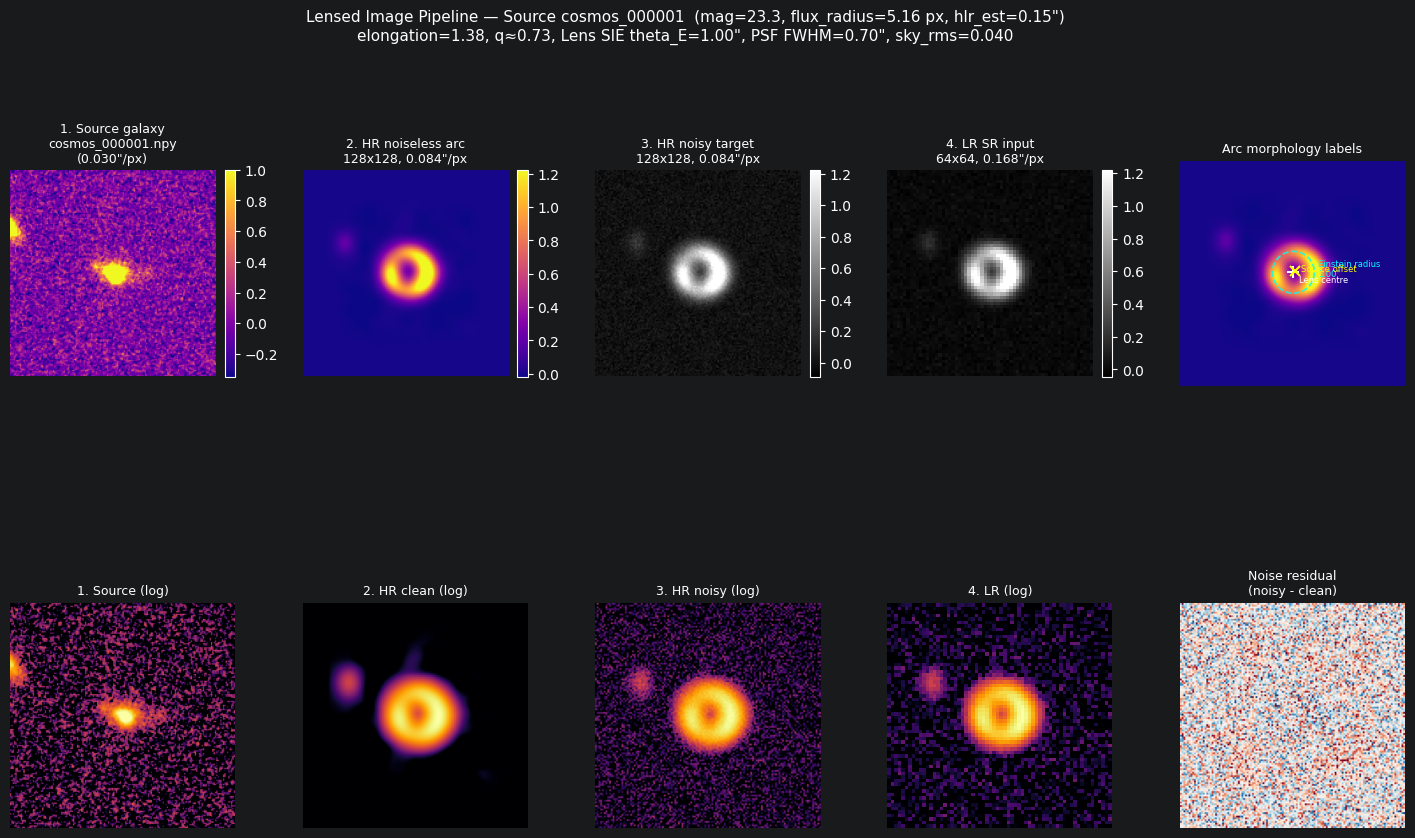

Saved: test_pair_detail.png


In [7]:
fig = plt.figure(figsize=(18, 10))

source_id = test_meta.get('source_id', 'unknown')
filename = test_meta.get('filename', 'unknown')
mag_auto = test_meta.get('mag_auto', np.nan)
flux_radius = test_meta.get('flux_radius', np.nan)
pixel_scale_arcsec = test_meta.get('pixel_scale_arcsec', SRC_PIX_SCALE)
elongation = test_meta.get('elongation', np.nan)
axis_ratio_est = test_meta.get('axis_ratio_est', np.nan)

hlr_arcsec_est = (
    float(flux_radius) * float(pixel_scale_arcsec)
    if pd.notna(flux_radius) and pd.notna(pixel_scale_arcsec)
    else np.nan
)

title_line1 = (
    f'Lensed Image Pipeline — Source {source_id}  '
    f'(mag={mag_auto:.1f}, '
    f'flux_radius={flux_radius:.2f} px, '
    f'hlr_est={hlr_arcsec_est:.2f}\")'
    if pd.notna(mag_auto) and pd.notna(flux_radius) and pd.notna(hlr_arcsec_est)
    else f'Lensed Image Pipeline — Source {source_id}'
)

title_line2 = (
    f'elongation={elongation:.2f}, q≈{axis_ratio_est:.2f}, '
    f'Lens SIE theta_E={result["params"]["theta_E"]:.2f}\", '
    f'PSF FWHM={result["params"]["psf_fwhm"]:.2f}\", '
    f'sky_rms={result["params"]["sky_rms"]:.3f}'
    if pd.notna(elongation) and pd.notna(axis_ratio_est)
    else f'Lens SIE theta_E={result["params"]["theta_E"]:.2f}\", '
         f'PSF FWHM={result["params"]["psf_fwhm"]:.2f}\", '
         f'sky_rms={result["params"]["sky_rms"]:.3f}'
)

fig.suptitle(f'{title_line1}\n{title_line2}', fontsize=11)

gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.35, wspace=0.3)

# Row 1: linear stretch
panels_top = [
    (test_src, f'1. Source galaxy\n{filename}\n({pixel_scale_arcsec:.3f}"/px)', 'plasma'),
    (hr_clean, f'2. HR noiseless arc\n{N_HR}x{N_HR}, {PIX_HR:.3f}"/px', 'plasma'),
    (hr_noisy, f'3. HR noisy target\n{N_HR}x{N_HR}, {PIX_HR:.3f}"/px', 'gray'),
    (lr_noisy, f'4. LR SR input\n{N_LR}x{N_LR}, {PIX_LR:.3f}"/px', 'gray'),
]

for col, (img, title, cmap) in enumerate(panels_top):
    ax = fig.add_subplot(gs[0, col])
    p1, p99 = np.percentile(img, [1, 99])
    im = ax.imshow(img, cmap=cmap, origin='lower', vmin=p1, vmax=p99)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Row 1 col 5: annotated arc diagram
ax_ann = fig.add_subplot(gs[0, 4])
p1, p99 = np.percentile(hr_clean, [0.5, 99.5])
ax_ann.imshow(hr_clean, cmap='plasma', origin='lower', vmin=p1, vmax=p99)
ax_ann.set_title('Arc morphology labels', fontsize=9)
ax_ann.axis('off')

cx, cy = N_HR // 2, N_HR // 2
theta_E_px = result['params']['theta_E'] / PIX_HR

circle = plt.Circle((cx, cy), theta_E_px, fill=False,
                    color='cyan', linewidth=1.2, linestyle='--', alpha=0.8)
ax_ann.add_patch(circle)
ax_ann.text(cx + theta_E_px + 2, cy + 2,
            f'Einstein radius\n{result["params"]["theta_E"]:.2f}"',
            color='cyan', fontsize=6, va='center')

ax_ann.plot(cx, cy, '+', color='white', markersize=8, markeredgewidth=1.5)
ax_ann.text(cx + 3, cy - 6, 'Lens centre', color='white', fontsize=6)

srcx_px = cx + result['params']['src_offset_x'] / PIX_HR
srcy_px = cy + result['params']['src_offset_y'] / PIX_HR
ax_ann.plot(srcx_px, srcy_px, 'x', color='yellow', markersize=7, markeredgewidth=1.5)
ax_ann.text(srcx_px + 3, srcy_px, 'Source offset', color='yellow', fontsize=6)

# Row 2: log stretch
panels_bot = [
    (test_src, '1. Source (log)'),
    (hr_clean, '2. HR clean (log)'),
    (hr_noisy, '3. HR noisy (log)'),
    (lr_noisy, '4. LR (log)'),
]

for col, (img, title) in enumerate(panels_bot):
    ax = fig.add_subplot(gs[1, col])
    img_log = np.log1p(np.clip(img, 0, None) * 50)
    ax.imshow(img_log, cmap='inferno', origin='lower')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

# Row 2 col 5: noise residual
ax_noise = fig.add_subplot(gs[1, 4])
noise_residual = hr_noisy - hr_clean
vext = np.percentile(np.abs(noise_residual), 99)
ax_noise.imshow(noise_residual, cmap='RdBu_r', origin='lower', vmin=-vext, vmax=vext)
ax_noise.set_title('Noise residual\n(noisy - clean)', fontsize=9)
ax_noise.axis('off')

plt.savefig(OUT_DIR / 'test_pair_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: test_pair_detail.png')

## Cell 8 — Vary source offset: from Einstein ring to partial arc

This shows the key relationship between source position and arc morphology:
- **Source exactly behind lens (offset=0)**: full Einstein ring
- **Small offset**: bright, nearly-complete arc
- **Large offset**: two separate image pairs ("fold" configuration)
- **Very large offset**: single unresolved demagnified image (no longer strongly lensed)

This is what your mentors mean by "arc morphology" — the range of shapes the training set should contain.

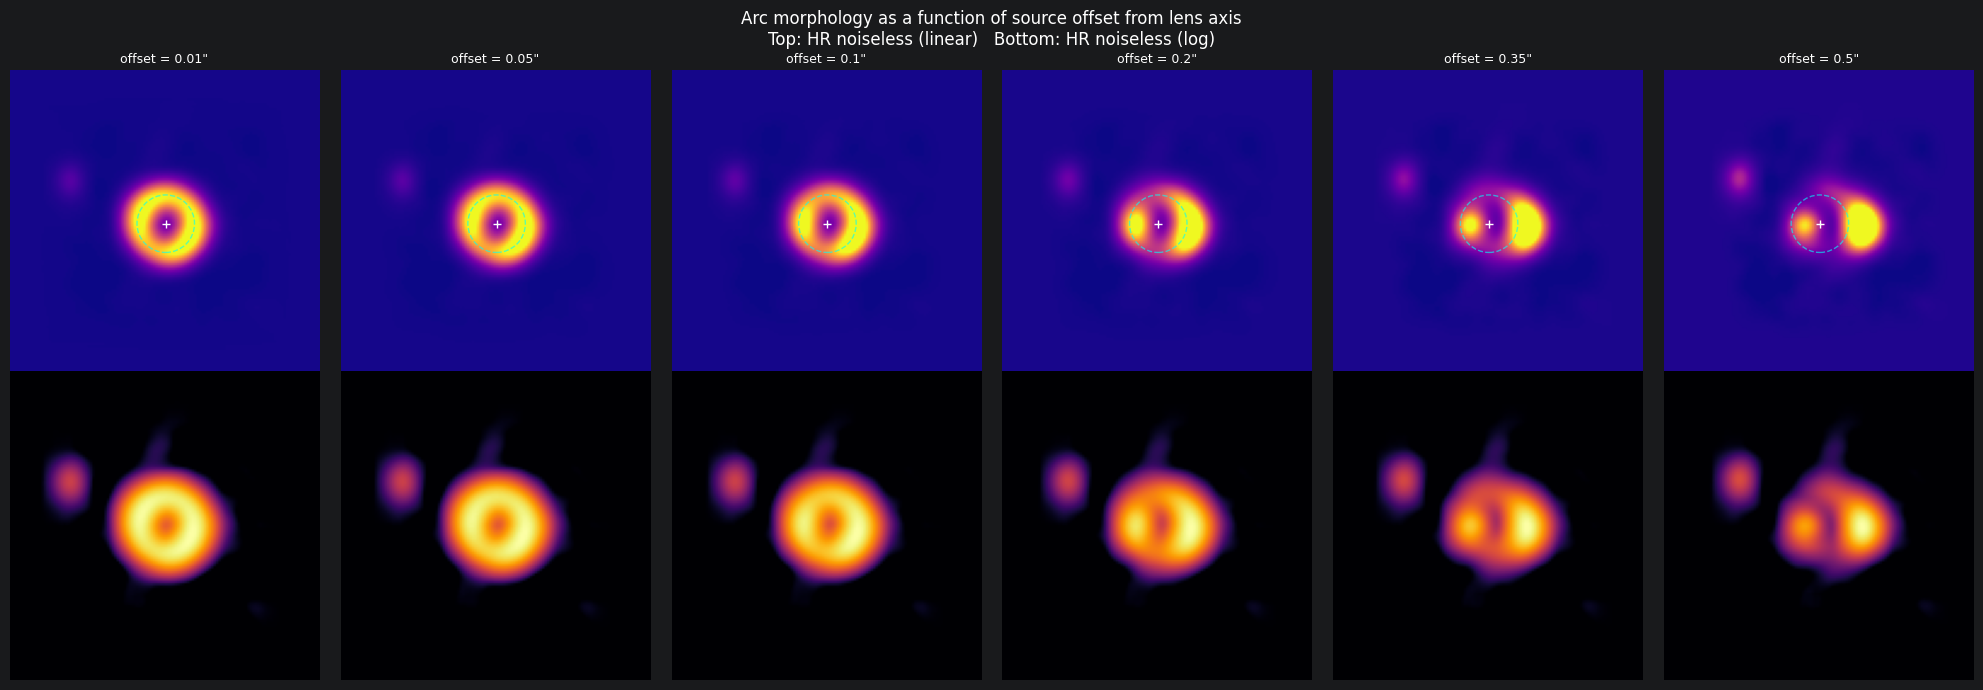

Saved: arc_morphology_vs_offset.png


In [8]:
# Test 6 source offsets from near-zero to large
# offset is in arcsec from the lens optical axis
test_offsets = [0.01, 0.05, 0.10, 0.20, 0.35, 0.50]

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle(
    'Arc morphology as a function of source offset from lens axis\n'
    'Top: HR noiseless (linear)   Bottom: HR noiseless (log)',
    fontsize=12
)

for col, offset in enumerate(test_offsets):
    res = simulate_lensed_pair(
        source_img   = source_galaxies[0],
        theta_E      = 1.0,
        src_offset_x = offset,
        src_offset_y = 0.0,
        src_amp      = 100.0,
        rng          = np.random.default_rng(42),
    )
    hr = res['hr_clean']

    # Einstein ring radius in pixels
    r_E = EINSTEIN_RADIUS / PIX_HR
    cx = cy = N_HR // 2

    # Top: linear stretch
    ax = axes[0, col]
    p1, p99 = np.percentile(hr, [1, 99])
    ax.imshow(hr, cmap='plasma', origin='lower', vmin=p1, vmax=p99)
    circ = plt.Circle((cx, cy), r_E, fill=False, color='cyan',
                       linewidth=1, linestyle='--', alpha=0.6)
    ax.add_patch(circ)
    ax.plot(cx, cy, '+w', markersize=6)
    ax.set_title(f'offset = {offset}"', fontsize=9)
    ax.axis('off')

    # Bottom: log stretch
    ax2 = axes[1, col]
    hr_log = np.log1p(np.clip(hr, 0, None) * 50)
    ax2.imshow(hr_log, cmap='inferno', origin='lower')
    ax2.axis('off')

# Label the arc types
arc_types = ['Einstein\nring', 'Near-\ncomplete arc',
             'Partial arc', 'Fold arc', 'Cusp arc', 'Faint arc']
for col, label in enumerate(arc_types):
    axes[1, col].set_xlabel(label, fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'arc_morphology_vs_offset.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: arc_morphology_vs_offset.png')

## Cell 9 — Vary PSF FWHM and noise level

Both PSF and noise vary across real HSC observations (different seeing, different exposure times).  
The SR model must handle the full range.

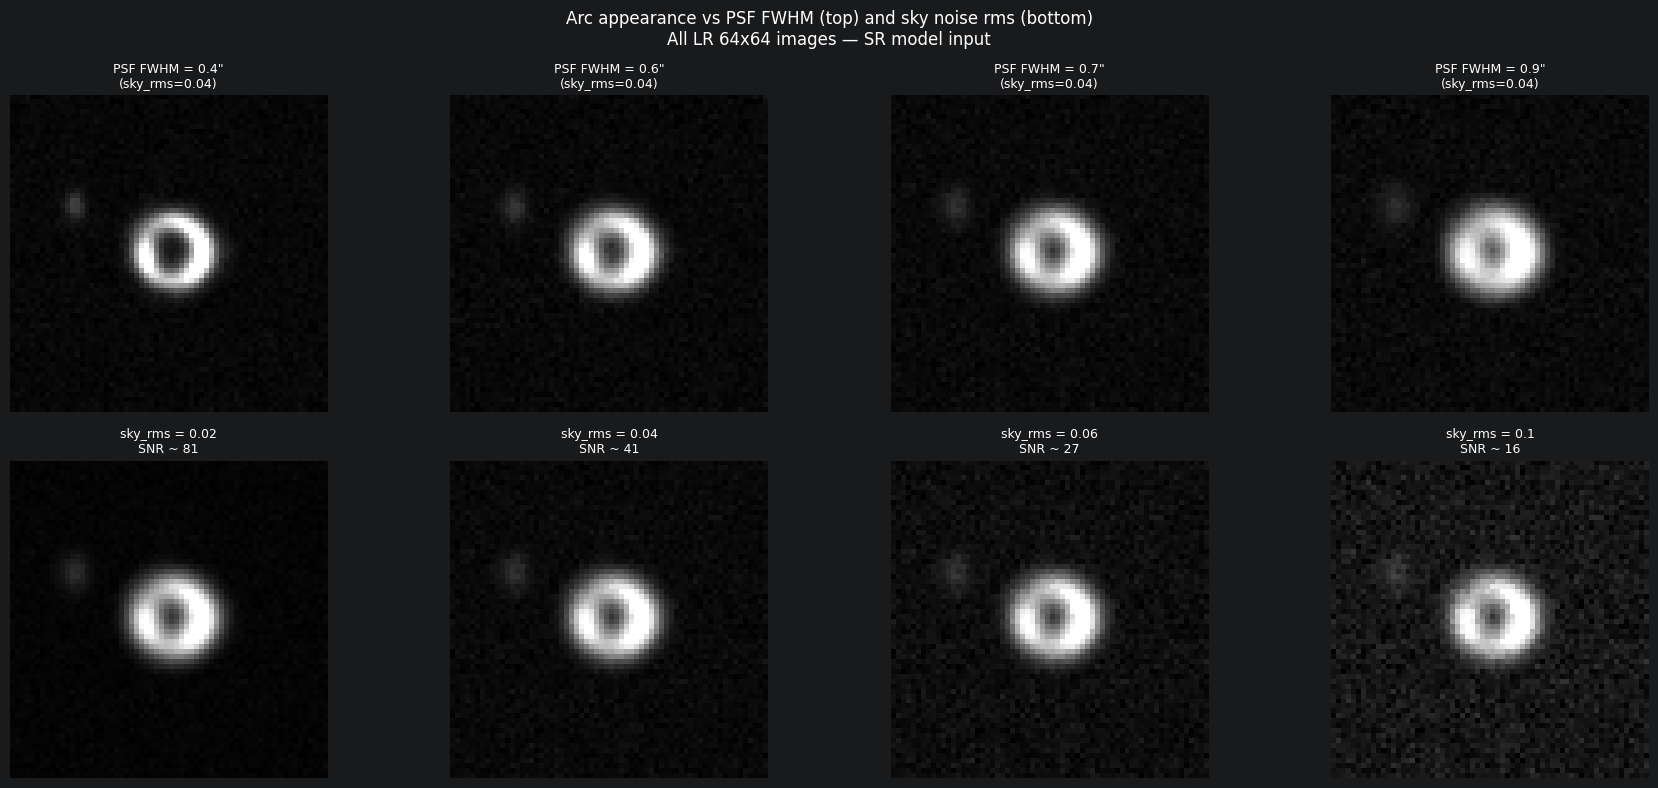

Saved: psf_noise_variation.png


In [9]:
psf_fwhms  = [0.4, 0.6, 0.7, 0.9]    # arcsec
sky_rmss   = [0.02, 0.04, 0.06, 0.10]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Arc appearance vs PSF FWHM (top) and sky noise rms (bottom)\n'
             'All LR 64x64 images — SR model input', fontsize=12)

# Top row: vary PSF
for col, fwhm in enumerate(psf_fwhms):
    res = simulate_lensed_pair(
        source_galaxies[0], theta_E=1.0,
        src_offset_x=0.1, src_offset_y=0.05, src_amp=100.0,
        psf_fwhm=fwhm, sky_rms=0.04,
        rng=np.random.default_rng(42),
    )
    lr = res['lr']
    p1, p99 = np.percentile(lr, [1, 99])
    axes[0, col].imshow(lr, cmap='gray', origin='lower', vmin=p1, vmax=p99)
    axes[0, col].set_title(f'PSF FWHM = {fwhm}"\n(sky_rms=0.04)', fontsize=9)
    axes[0, col].axis('off')

# Bottom row: vary noise
for col, srms in enumerate(sky_rmss):
    res = simulate_lensed_pair(
        source_galaxies[0], theta_E=1.0,
        src_offset_x=0.1, src_offset_y=0.05, src_amp=100.0,
        psf_fwhm=0.7, sky_rms=srms,
        rng=np.random.default_rng(42),
    )
    lr = res['lr']
    snr = res['hr_clean'].max() / srms
    p1, p99 = np.percentile(lr, [1, 99])
    axes[1, col].imshow(lr, cmap='gray', origin='lower', vmin=p1, vmax=p99)
    axes[1, col].set_title(f'sky_rms = {srms}\nSNR ~ {snr:.0f}', fontsize=9)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'psf_noise_variation.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: psf_noise_variation.png')

## Cell 10 — Simulate 10 diverse pairs (different source galaxies)

Run the full pipeline across 10 different source galaxies with randomised lens parameters.

In [10]:
N_PAIRS   = min(10, len(source_galaxies))
rng_local = np.random.default_rng(RNG_SEED)

batch_results = []
batch_meta    = []

print(f'Simulating {N_PAIRS} diverse lensed pairs ...')

for i in tqdm(range(N_PAIRS), desc='Simulating'):
    src = source_galaxies[i]
    src_meta = matched_meta.iloc[i].copy()

    theta_E = rng_local.uniform(0.8, 1.3)
    e1 = rng_local.uniform(-0.15, 0.15)
    e2 = rng_local.uniform(-0.15, 0.15)

    r_src = rng_local.uniform(0.02, 0.35)
    phi_src = rng_local.uniform(0, 2 * np.pi)
    ox = float(r_src * np.cos(phi_src))
    oy = float(r_src * np.sin(phi_src))

    rotation = rng_local.uniform(0, 2 * np.pi)
    amp = rng_local.uniform(50.0, 150.0)
    psf_fwhm = rng_local.uniform(0.55, 0.85)
    sky_rms = rng_local.uniform(0.03, 0.06)

    res = simulate_lensed_pair(
        source_img = src,
        theta_E = theta_E,
        lens_e1 = e1,
        lens_e2 = e2,
        src_offset_x = ox,
        src_offset_y = oy,
        src_rotation = rotation,
        src_amp = amp,
        psf_fwhm = psf_fwhm,
        sky_rms = sky_rms,
        rng = np.random.default_rng(rng_local.integers(0, 999999)),
    )

    sim_id = f'{i:04d}'
    np.save(OUT_DIR / 'hr' / f'hr_{sim_id}.npy', res['hr'])
    np.save(OUT_DIR / 'lr' / f'lr_{sim_id}.npy', res['lr'])

    batch_results.append(res)
    batch_meta.append({
        'sim_id': sim_id,
        'src_index': i,
        'source_id': src_meta.get('source_id'),
        'filename': src_meta.get('filename'),
        'mag_auto': src_meta.get('mag_auto'),
        'flux_radius': src_meta.get('flux_radius'),
        'pixel_scale_arcsec': src_meta.get('pixel_scale_arcsec'),
        'hlr_arcsec_est': (
            float(src_meta['flux_radius']) * float(src_meta['pixel_scale_arcsec'])
            if pd.notna(src_meta.get('flux_radius')) and pd.notna(src_meta.get('pixel_scale_arcsec'))
            else np.nan
        ),
        'elongation': src_meta.get('elongation'),
        'axis_ratio_est': src_meta.get('axis_ratio_est'),
        'arc_snr': float(res['hr_clean'].max() / sky_rms),
        **res['params']
    })

pd.DataFrame(batch_meta).to_csv(OUT_DIR / 'simulation_metadata.csv', index=False)
print(f'\nSaved {N_PAIRS} HR/LR pairs.')
print(f'Metadata saved: {OUT_DIR}/simulation_metadata.csv')

snrs = [m['arc_snr'] for m in batch_meta]
print(f'\nArc SNR range: {min(snrs):.1f} – {max(snrs):.1f} (mean: {np.mean(snrs):.1f})')

Simulating 10 diverse lensed pairs ...


Simulating:   0%|          | 0/10 [00:00<?, ?it/s]


Saved 10 HR/LR pairs.
Metadata saved: lensing_sim_output/simulation_metadata.csv

Arc SNR range: 16.6 – 50.1 (mean: 29.2)


## Cell 11 — Grid of all 10 simulated LR images

Verify morphological diversity across different source galaxies and lens configurations.

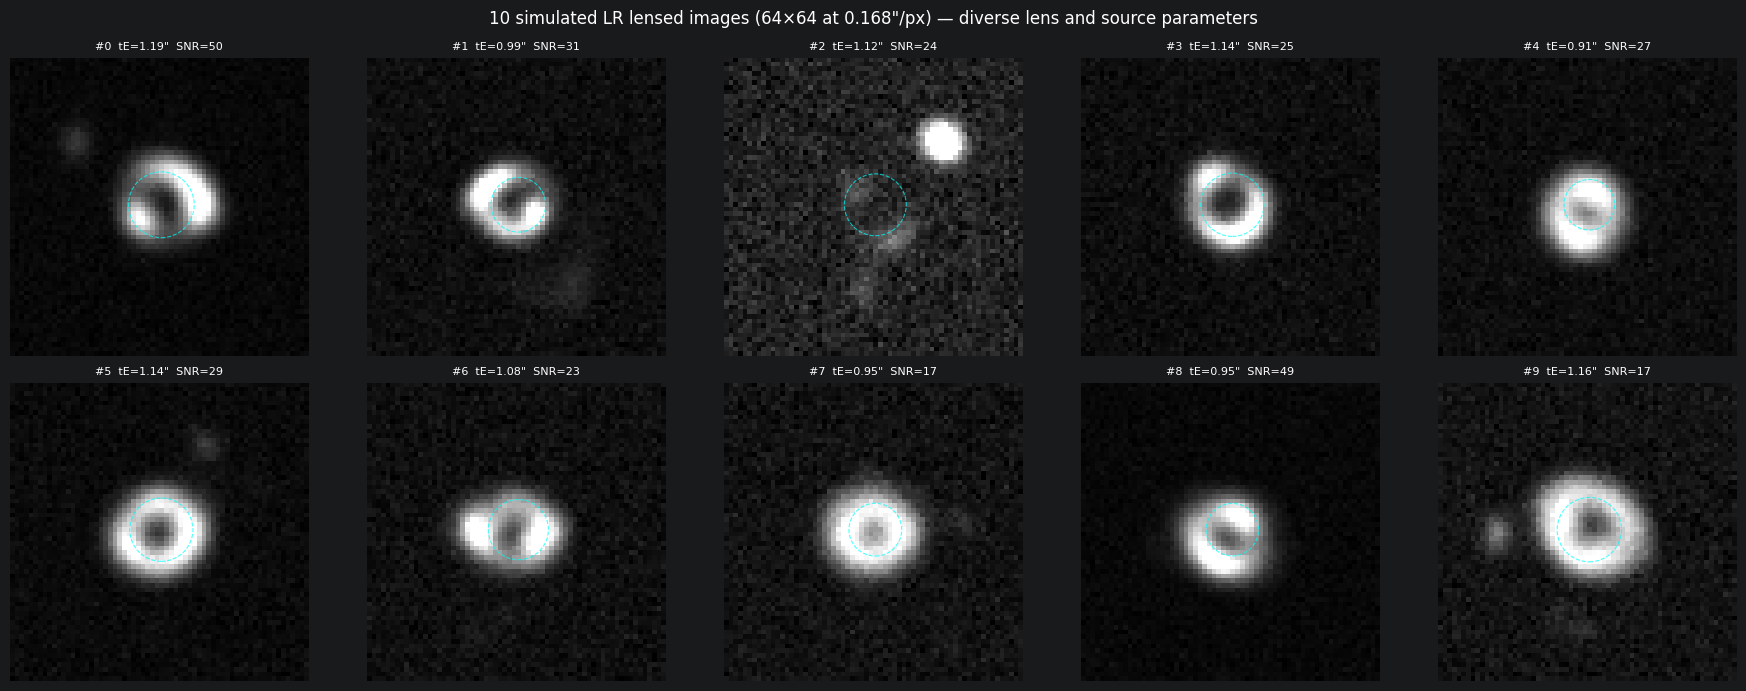

Saved: lr_grid_10.png


In [11]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('10 simulated LR lensed images (64×64 at 0.168"/px) — diverse lens and source parameters',
             fontsize=12)

for i, (res, meta) in enumerate(zip(batch_results, batch_meta)):
    ax  = axes[i // 5, i % 5]
    lr  = res['lr']
    p1, p99 = np.percentile(lr, [1, 99])
    ax.imshow(lr, cmap='gray', origin='lower', vmin=p1, vmax=p99)

    # Einstein ring circle at LR scale
    cx = cy = N_LR // 2
    r_E = meta['theta_E'] / PIX_LR
    circ = plt.Circle((cx, cy), r_E, fill=False, color='cyan',
                       linewidth=0.8, linestyle='--', alpha=0.7)
    ax.add_patch(circ)

    ax.set_title(
        f'#{i}  tE={meta["theta_E"]:.2f}"  SNR={meta["arc_snr"]:.0f}',
        fontsize=8
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'lr_grid_10.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lr_grid_10.png')

## Cell 12 — Side-by-side HR vs LR comparison

Shows the resolution degradation your SR model must reverse.

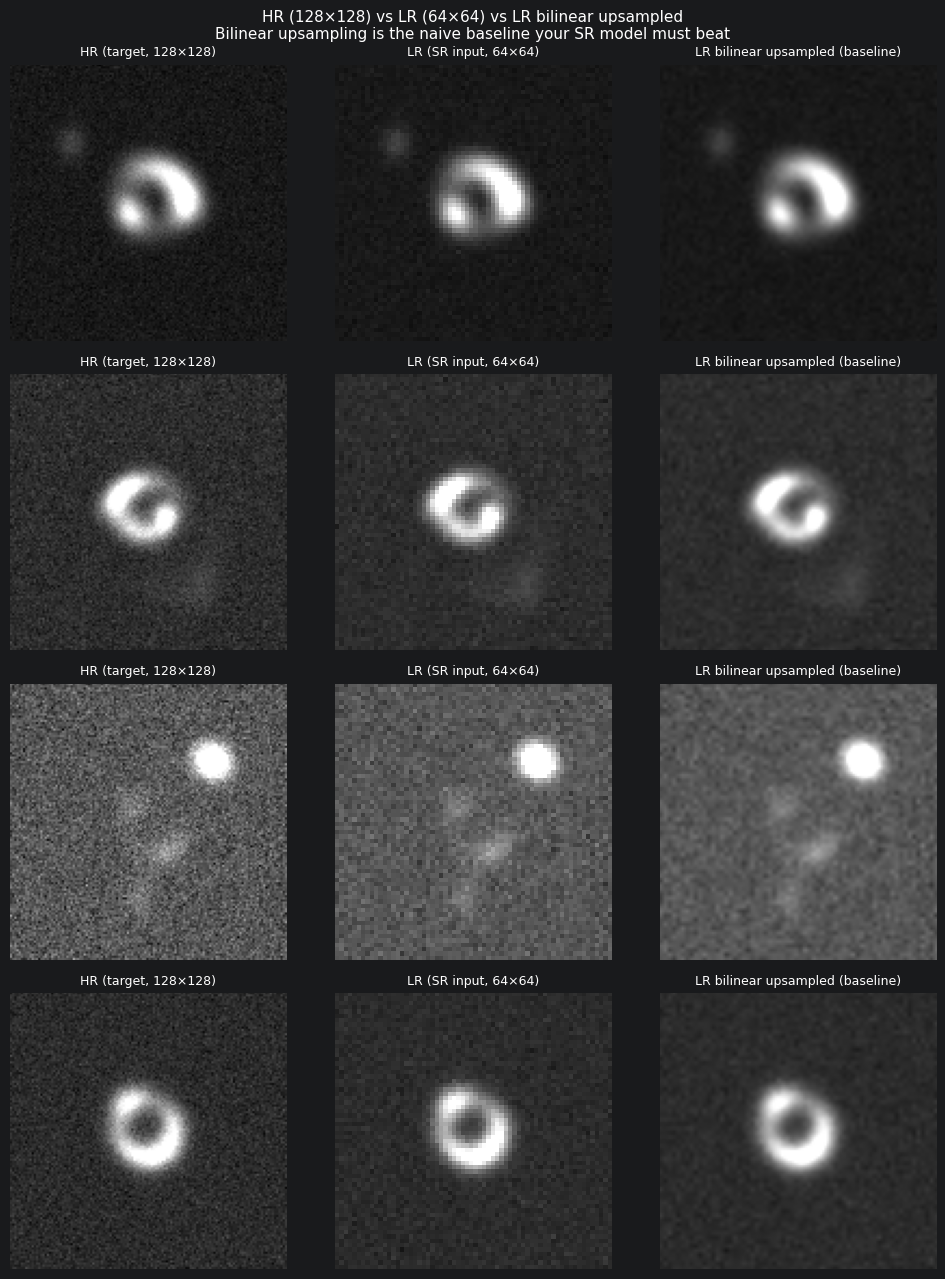

Saved: hr_lr_comparison.png


In [12]:
# Show the first 4 pairs side by side: HR | LR | LR upsampled (bilinear)
fig, axes = plt.subplots(4, 3, figsize=(10, 13))
fig.suptitle('HR (128×128) vs LR (64×64) vs LR bilinear upsampled\n'
             'Bilinear upsampling is the naive baseline your SR model must beat',
             fontsize=11)

for row, res in enumerate(batch_results[:4]):
    hr   = res['hr']
    lr   = res['lr']
    # Bilinear upsample LR to HR size for visual comparison
    lr_up = zoom(lr, 2.0, order=1).astype(np.float32)  # order=1 = bilinear

    vmin  = min(hr.min(), lr_up.min())
    vmax  = np.percentile(hr, 99)

    axes[row, 0].imshow(hr,    cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    axes[row, 0].set_title('HR (target, 128×128)', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(lr,    cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    axes[row, 1].set_title('LR (SR input, 64×64)', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(lr_up, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    axes[row, 2].set_title('LR bilinear upsampled (baseline)', fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'hr_lr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: hr_lr_comparison.png')

## Cell 13 — Arc morphology validation against real HSC images

### What we are checking and why

Your simulated arcs need to look plausible for the HSC instrument. The comparison is **qualitative**  
(visual inspection) not quantitative — you are checking:

| Feature | What to look for | Adjustment if wrong |
|---------|-----------------|--------------------|
| **Arc radius** | Arc appears at ~1"–1.5" from lens centre | Adjust `theta_E` range (0.8–1.3" is standard) |
| **Arc brightness vs noise** | Arc visible but not unrealistically bright | Adjust `src_amp` and `sky_rms` |
| **Arc thickness** | Comparable to a source size of 0.1"–0.5" | Reflects real COSMOS `hlr_arcsec` |
| **PSF blur** | Arc edges are smooth, not pixel-sharp | Adjust `psf_fwhm` (0.6–0.9" for HSC) |
| **Noise texture** | Sky background has realistic grainy appearance | Adjust `sky_rms` (0.03–0.05) |
| **Arc curvature** | Arcs are curved, not straight lines | Inherent in SIE — no adjustment needed |

### How to get real HSC reference images

**Option A (easiest):** Ask your mentors for a few HSC cutouts from the DiffLense training set.  
The DiffLense paper (Reddy et al. 2024) used a real matched HSC-HST dataset of 173 objects —  
these are the gold standard comparison targets.

**Option B:** Use the HSC SSP public data release browser:  
https://hsc-release.mtk.nao.ac.jp/doc/ (requires free registration)  
Known HSC strong lenses: SuGOHI catalog (Sonnenfeld et al. 2018, 2020)

**Option C (immediate):** The DiffLense paper Figure 2-3 show side-by-side HSC/HST cutouts  
which you can use for visual reference. The paper is in your project files.

The cell below:
1. Shows your simulated LR images at the same visual scale as real HSC cutouts
2. Loads a real HSC reference image if you provide one (see instructions)
3. Computes pixel-level statistics for comparison (mean, std, dynamic range)

In [13]:
# ── INSTRUCTIONS ──────────────────────────────────────────────────────────────
# If you have a real HSC lensing image (.npy or .fits), set this path.
# If not, ask your mentors or set REAL_HSC_PATH = None to skip the comparison.
#
# Acceptable format:
#   - .npy file: float32 array of shape (64, 64) at 0.168"/px (normalised to ~[0,1])
#   - .fits file: will be read automatically below
REAL_HSC_PATH = None   # <-- set this to Path('your_hsc_image.npy') once available
# ── END INSTRUCTIONS ──────────────────────────────────────────────────────────


def load_real_hsc_image(path):
    """Load a real HSC lensing image from .npy or .fits."""
    path = Path(path)
    if path.suffix == '.npy':
        img = np.load(path).astype(np.float32)
    elif path.suffix in ('.fits', '.fit'):
        from astropy.io import fits as astrofits
        with astrofits.open(path) as hdul:
            img = hdul[0].data.astype(np.float32)
    else:
        raise ValueError(f'Unsupported format: {path.suffix}')
    # Normalise to [0, 1]
    img = np.squeeze(img)
    p99 = np.percentile(img, 99)
    if p99 > 0:
        img = np.clip(img / p99, 0, 1)
    return img


def compute_image_statistics(img, label):
    """Print a set of image statistics for comparison."""
    print(f'  {label:35s} : '
          f'mean={img.mean():.4f}  std={img.std():.4f}  '
          f'max={img.max():.4f}  '
          f'sky_proxy={np.percentile(img, 10):.4f}')


# ── Compute statistics for all simulated LR images ────────────────────────────
print('=== Simulated LR image statistics ===')
for i, res in enumerate(batch_results):
    compute_image_statistics(res['lr'], f'Sim LR #{i:02d} (SNR={batch_meta[i]["arc_snr"]:.0f})')

# ── Load and compare real HSC image if available ──────────────────────────────
real_hsc = None
if REAL_HSC_PATH is not None and Path(REAL_HSC_PATH).exists():
    real_hsc = load_real_hsc_image(REAL_HSC_PATH)
    print(f'\n=== Real HSC image statistics ===')
    compute_image_statistics(real_hsc, 'Real HSC image')
else:
    print('\n[INFO] No real HSC image provided.')
    print('  Set REAL_HSC_PATH at the top of this cell once you have one.')
    print('  Ask your mentors for HSC cutouts from the DiffLense dataset.')
    print('  Or check the DiffLense paper Figure 2 for visual reference.')

=== Simulated LR image statistics ===
  Sim LR #00 (SNR=50)                 : mean=0.0609  std=0.2044  max=1.6819  sky_proxy=-0.0199
  Sim LR #01 (SNR=31)                 : mean=0.0508  std=0.1896  max=1.6689  sky_proxy=-0.0324
  Sim LR #02 (SNR=24)                 : mean=0.0096  std=0.0515  max=0.7433  sky_proxy=-0.0189
  Sim LR #03 (SNR=25)                 : mean=0.0422  std=0.1515  max=1.1179  sky_proxy=-0.0262
  Sim LR #04 (SNR=27)                 : mean=0.0499  std=0.1715  max=1.1248  sky_proxy=-0.0242
  Sim LR #05 (SNR=29)                 : mean=0.0711  std=0.2164  max=1.3098  sky_proxy=-0.0255
  Sim LR #06 (SNR=23)                 : mean=0.0444  std=0.1490  max=1.0539  sky_proxy=-0.0277
  Sim LR #07 (SNR=17)                 : mean=0.0374  std=0.1178  max=0.6608  sky_proxy=-0.0231
  Sim LR #08 (SNR=49)                 : mean=0.0584  std=0.1962  max=1.4809  sky_proxy=-0.0176
  Sim LR #09 (SNR=17)                 : mean=0.0482  std=0.1279  max=0.6805  sky_proxy=-0.0220

[INFO] No r

## Cell 14 — Side-by-side morphology comparison (simulated vs real HSC)

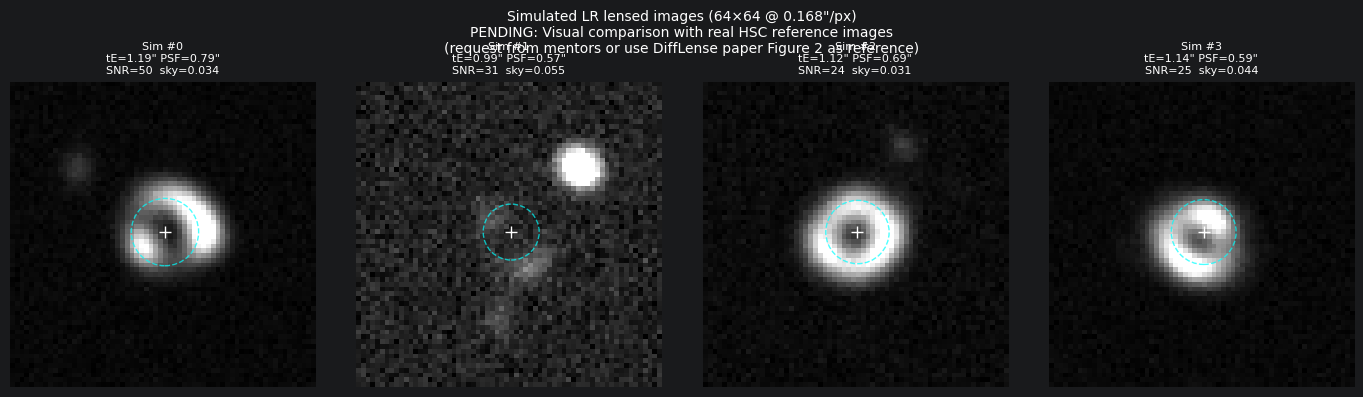

Saved: sim_images_for_comparison.png

NEXT STEP: Send sim_images_for_comparison.png to your mentors
and ask them to confirm the arc morphology looks realistic for HSC.


In [14]:
# Select 4 representative simulated images
sim_examples = [batch_results[i]['lr'] for i in [0, 2, 5, 8][:min(4, N_PAIRS)]]

if real_hsc is not None:
    # Show real HSC alongside simulated
    n_cols = len(sim_examples) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 3.2, 3.5))

    axes[0].imshow(real_hsc, cmap='gray', origin='lower',
                   vmin=np.percentile(real_hsc, 1),
                   vmax=np.percentile(real_hsc, 99))
    axes[0].set_title('REAL HSC\n(reference)', fontsize=10, color='orange')
    axes[0].axis('off')
    # Thick border to distinguish
    for spine in axes[0].spines.values():
        spine.set_edgecolor('orange')
        spine.set_linewidth(2)

    for col, sim_lr in enumerate(sim_examples, start=1):
        axes[col].imshow(sim_lr, cmap='gray', origin='lower',
                         vmin=np.percentile(sim_lr, 1),
                         vmax=np.percentile(sim_lr, 99))
        axes[col].set_title(f'Simulated #{col-1}\n(64×64, HSC spec)', fontsize=10)
        axes[col].axis('off')

    fig.suptitle('Arc morphology: real HSC vs simulated lensed images\n'
                 'Compare: arc radius, arc brightness, noise texture, PSF blur',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'sim_vs_real_hsc.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: sim_vs_real_hsc.png')

else:
    # No real image — show simulation-only comparison with annotations
    fig, axes = plt.subplots(1, len(sim_examples), figsize=(len(sim_examples) * 3.5, 4))
    fig.suptitle(
        'Simulated LR lensed images (64×64 @ 0.168"/px)\n'
        'PENDING: Visual comparison with real HSC reference images\n'
        '(request from mentors or use DiffLense paper Figure 2 as reference)',
        fontsize=10
    )

    for col, sim_lr in enumerate(sim_examples):
        ax = axes[col] if len(sim_examples) > 1 else axes
        p1, p99 = np.percentile(sim_lr, [1, 99])
        ax.imshow(sim_lr, cmap='gray', origin='lower', vmin=p1, vmax=p99)

        # Annotate arc features
        cx = cy = N_LR // 2
        r_E = batch_meta[col]['theta_E'] / PIX_LR
        circ = plt.Circle((cx, cy), r_E, fill=False, color='cyan',
                           linewidth=1.0, linestyle='--', alpha=0.7)
        ax.add_patch(circ)
        ax.plot(cx, cy, '+', color='white', markersize=8)

        ax.set_title(
            f'Sim #{col}\n'
            f'tE={batch_meta[col]["theta_E"]:.2f}" '
            f'PSF={batch_meta[col]["psf_fwhm"]:.2f}"\n'
            f'SNR={batch_meta[col]["arc_snr"]:.0f}  '
            f'sky={batch_meta[col]["sky_rms"]:.3f}',
            fontsize=8
        )
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'sim_images_for_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: sim_images_for_comparison.png')
    print()
    print('NEXT STEP: Send sim_images_for_comparison.png to your mentors')
    print('and ask them to confirm the arc morphology looks realistic for HSC.')

## Cell 15 — Quantitative arc morphology metrics

These metrics help you judge simulation quality when you don't have a real reference image.

| Metric | Expected range for HSC strong lenses | Reference |
|--------|--------------------------------------|----------|
| Einstein ring radius | 0.8" – 1.3" (5–8 LR pixels) | Alexander et al. 2021 |
| Peak arc flux / sky_rms (arc SNR) | 5 – 50 | DiffLense training data |
| Fraction of pixels above 2σ | 5% – 20% | Arc vs. background |
| Arc FWHM in radial direction | 0.5" – 1.5" | Reflects source size + PSF |

In [15]:
print('=== Quantitative arc morphology metrics ===')
print(f'{"Sim":<6} {"theta_E":>8} {"Arc SNR":>10} {"Above 2sig":>12} '
      f'{"PSF FWHM":>10} {"sky_rms":>10}')
print('-' * 62)

for i, (res, meta) in enumerate(zip(batch_results, batch_meta)):
    lr      = res['lr']
    sky_rms = meta['sky_rms']

    arc_snr       = res['hr_clean'].max() / sky_rms
    frac_bright   = (lr > 2 * sky_rms).mean() * 100
    theta_E       = meta['theta_E']
    psf_fwhm      = meta['psf_fwhm']

    print(f'#{i:<5} {theta_E:>8.2f}" {arc_snr:>10.1f} '
          f'{frac_bright:>11.1f}% {psf_fwhm:>9.2f}" {sky_rms:>10.3f}')

print('-' * 62)
print(f'Expected SNR range for HSC training data: 5 – 50')
print(f'Expected frac_bright range: 5% – 20%')

=== Quantitative arc morphology metrics ===
Sim     theta_E    Arc SNR   Above 2sig   PSF FWHM    sky_rms
--------------------------------------------------------------
#0         1.19"       50.1        12.9%      0.79"      0.034
#1         0.99"       30.9         8.8%      0.57"      0.055
#2         1.12"       24.1         3.2%      0.69"      0.031
#3         1.14"       25.2         9.3%      0.59"      0.044
#4         0.91"       26.9         9.9%      0.79"      0.042
#5         1.14"       29.3        12.8%      0.78"      0.044
#6         1.08"       23.0        10.1%      0.74"      0.047
#7         0.95"       16.6        10.6%      0.57"      0.038
#8         0.95"       48.9        12.0%      0.60"      0.031
#9         1.16"       16.7        14.1%      0.66"      0.039
--------------------------------------------------------------
Expected SNR range for HSC training data: 5 – 50
Expected frac_bright range: 5% – 20%


## Cell 16 — Final summary and validation checklist

In [16]:
sim_meta_df = pd.DataFrame(batch_meta)

print('=' * 65)
print('STAGE 0 LENSING SIMULATION PROTOTYPE — COMPLETE')
print('=' * 65)
print(f'  Simulated pairs         : {N_PAIRS}')
print(f'  HR size                 : {N_HR}x{N_HR} at {PIX_HR}"/px')
print(f'  LR size                 : {N_LR}x{N_LR} at {PIX_LR}"/px')
print(f'  Lens model              : SIE (Singular Isothermal Ellipsoid)')
print(f'  Source model            : INTERPOL (real COSMOS RealGalaxy)')
print(f'  PSF model               : Moffat (beta={PSF_MOFFAT_BETA})')
print(f'  Noise model             : Poisson + Gaussian (HSC levels)')
print(f'  Arc SNR range (simulated): {sim_meta_df["arc_snr"].min():.0f} – {sim_meta_df["arc_snr"].max():.0f}')
print()
print('Output files:')
print(f'  lensing_sim_output/hr/hr_XXXX.npy  ({N_PAIRS} files, 128x128 float32)')
print(f'  lensing_sim_output/lr/lr_XXXX.npy  ({N_PAIRS} files, 64x64 float32)')
print(f'  lensing_sim_output/simulation_metadata.csv')
print()
print('VALIDATION CHECKLIST (tick off before proceeding to Stage 1):')
print('  [ ] Arc radius matches Einstein ring circle (cyan dashed circle)')
print('  [ ] Arc brightness is realistic (SNR 5-50 range)')
print('  [ ] Noise texture looks like real HSC background')
print('  [ ] PSF blur is comparable to mentors HSC reference images')
print('  [ ] Arc morphology varies (Einstein ring, partial arc, fold arc)')
print('  [ ] Send sim_images_for_comparison.png to mentors for sign-off')
print()
print('THINGS TO AGREE WITH MENTORS BEFORE 03_full_pipeline.py:')
print('  1. Final PSF FWHM distribution (min, max, shape — uniform or Gaussian?)')
print('  2. Final sky_rms distribution (calibrated to HSC wide vs deep survey)')
print('  3. Substructure variants: particle subhalo mass fraction range')
print('  4. Confirm src_amp range gives arc SNR consistent with DiffLense dataset')
print('=' * 65)

STAGE 0 LENSING SIMULATION PROTOTYPE — COMPLETE
  Simulated pairs         : 10
  HR size                 : 128x128 at 0.084"/px
  LR size                 : 64x64 at 0.168"/px
  Lens model              : SIE (Singular Isothermal Ellipsoid)
  Source model            : INTERPOL (real COSMOS RealGalaxy)
  PSF model               : Moffat (beta=3.0)
  Noise model             : Poisson + Gaussian (HSC levels)
  Arc SNR range (simulated): 17 – 50

Output files:
  lensing_sim_output/hr/hr_XXXX.npy  (10 files, 128x128 float32)
  lensing_sim_output/lr/lr_XXXX.npy  (10 files, 64x64 float32)
  lensing_sim_output/simulation_metadata.csv

VALIDATION CHECKLIST (tick off before proceeding to Stage 1):
  [ ] Arc radius matches Einstein ring circle (cyan dashed circle)
  [ ] Arc brightness is realistic (SNR 5-50 range)
  [ ] Noise texture looks like real HSC background
  [ ] PSF blur is comparable to mentors HSC reference images
  [ ] Arc morphology varies (Einstein ring, partial arc, fold arc)
  [ ] Se